# Customer Churn Prediction Project

## Objective
The objective of this project is to identify customers who are likely to churn using demographic, service usage, and billing information. The model aims to assist businesses in prioritizing retention strategies.

In [80]:
#importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)
import pickle

In [ ]:
#loading the dataset
df = pd.read_excel('D:/Customer_churn_prediction/data/raw/dataset2_v2.xlsx', engine="openpyxl")
df = df.copy()
df.head()


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


# Basic EDA

In [82]:
#checking the shape, info, duplicates and summary statistics of the dataset
df.shape
df.info()
df.duplicated().sum()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [83]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
df['Total Charges'].isna().sum()
df['Total Charges'].fillna(df['Total Charges'].median(), inplace=True)

C:\Users\anupo\AppData\Local\Temp\ipykernel_21636\2560312815.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Total Charges'].fillna(df['Total Charges'].median(), inplace=True)


0        108.15
1        151.65
2        820.50
3       3046.05
4       5036.30
         ...   
7038    1419.40
7039    1990.50
7040    7362.90
7041     346.45
7042    6844.50
Name: Total Charges, Length: 7043, dtype: float64

No duplicate records were found. No missing values were detected in the dataset. The dataset appears clean and ready for preprocessing.

In [84]:
#checking the distribution of the target variable 'Churn Value'
churn_percent = (
    df['Churn Value']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(f"Non-Churn Customers: {churn_percent[0]}%")
print(f"Churn Customers: {churn_percent[1]}%")

Non-Churn Customers: 73.46%
Churn Customers: 26.54%


In [85]:
#checking the distribution of categorical and numerical features
categorical_cols = df.select_dtypes(include='object').columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

C:\Users\anupo\AppData\Local\Temp\ipykernel_21636\3631568546.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns


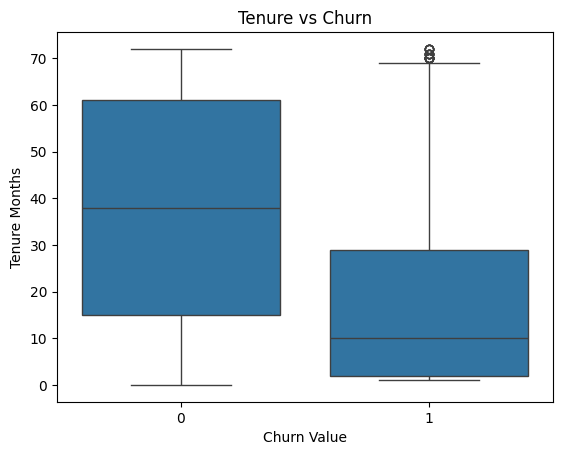

In [86]:
#visualizing the relationship between 'Tenure Months' and 'Churn Value'
sns.boxplot(x='Churn Value', y='Tenure Months', data=df)
plt.title('Tenure vs Churn')
plt.show()

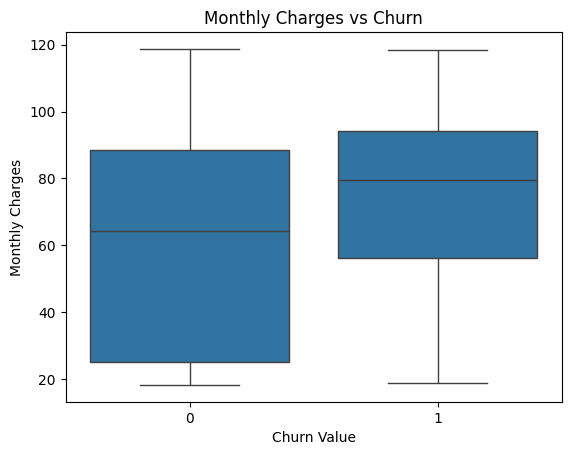

In [87]:
#visualizing the relationship between 'Monthly Charges' and 'Churn Value'
sns.boxplot(x='Churn Value', y='Monthly Charges', data=df)
plt.title('Monthly Charges vs Churn')
plt.show()

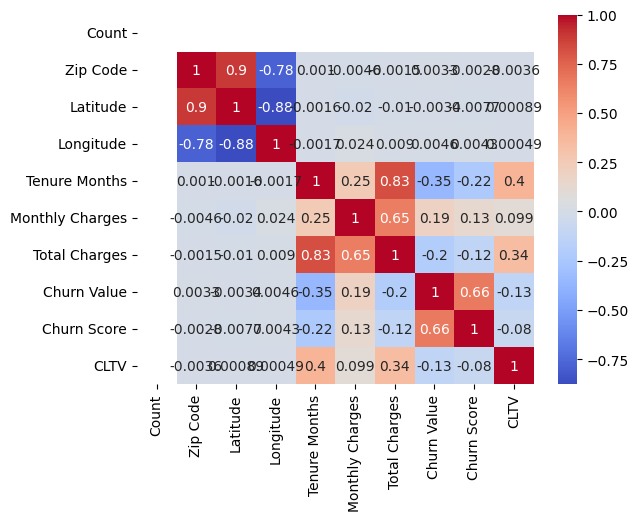

In [88]:
#visualizing the correlation between numerical features
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm')
plt.show()

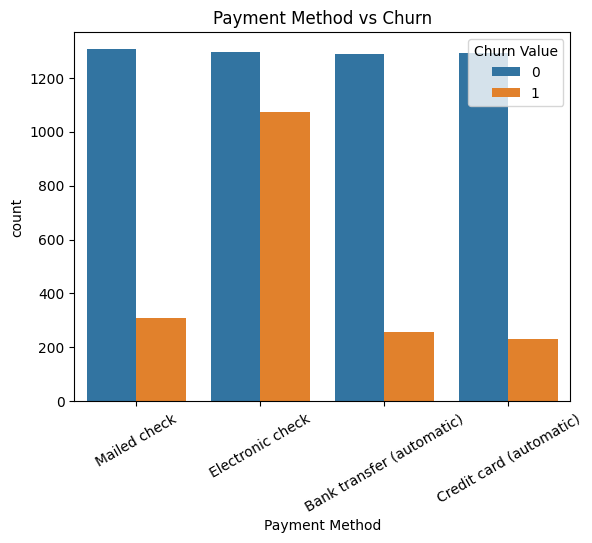

In [89]:
#visualizing the relationship between 'Payment Method' and 'Churn Value'
sns.countplot(x='Payment Method', hue='Churn Value', data=df)
plt.xticks(rotation=30)
plt.title('Payment Method vs Churn')
plt.show()

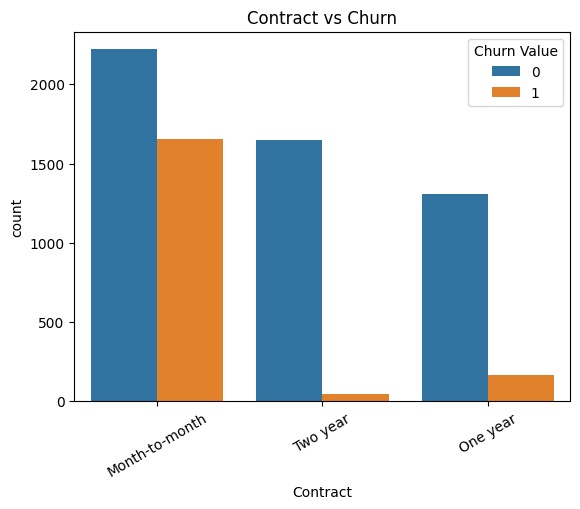

In [90]:
#visualizing the relationship between 'Contract' and 'Churn Value'
sns.countplot(x='Contract', hue='Churn Value', data=df)
plt.xticks(rotation=30)
plt.title('Contract vs Churn')
plt.show()

# Feature Engineering

In [91]:
#preparing the data for modeling
y = df['Churn Value']
X = df.drop(columns=['Churn Value'])

In [92]:
#dropping irrelevant columns that won't contribute to the model
columns_to_drop = [
    'CustomerID',
    'Country',
    'State',
    'Count',
    'Churn Label',
    'Churn Reason',
    'CLTV',
    'Lat Long',
    'City',
    'Zip Code'
]

X = X.drop(columns=columns_to_drop)

In [93]:
#identifying categorical and numerical features for preprocessing
categorical_features = X.select_dtypes(include='object').columns.tolist()
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

C:\Users\anupo\AppData\Local\Temp\ipykernel_21636\3144851570.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include='object').columns.tolist()


In [94]:
#creating pipelines for numerical and categorical features
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, numerical_features),
        ('cat', cat_pipeline, categorical_features)
    ]
)

In [95]:
#splitting the data into training and testing sets with stratification to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [97]:
#creating a pipeline that combines preprocessing and logistic regression model with class weighting to handle class imbalance
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
])

model.fit(X_train, y_train)
# Save Logistic Regression
with open("../models/logistic_model.pkl", "wb") as f:
    pickle.dump(model, f)



In [99]:
with open("../models/logistic_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)
    print("Model loaded successfully!")

Model loaded successfully!


In [ ]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

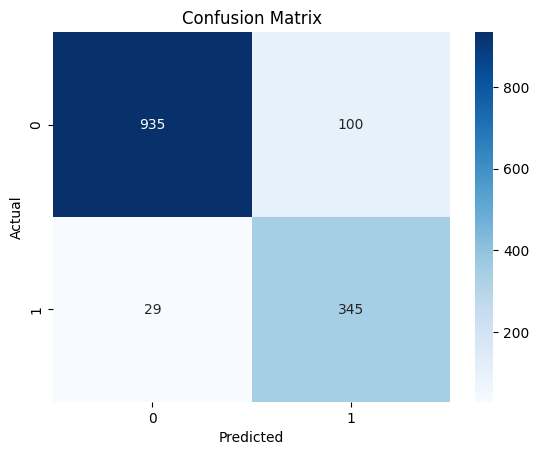

In [ ]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.90      0.94      1035
           1       0.78      0.92      0.84       374

    accuracy                           0.91      1409
   macro avg       0.87      0.91      0.89      1409
weighted avg       0.92      0.91      0.91      1409



In [ ]:
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", round(roc_auc, 4))

ROC-AUC Score: 0.9742


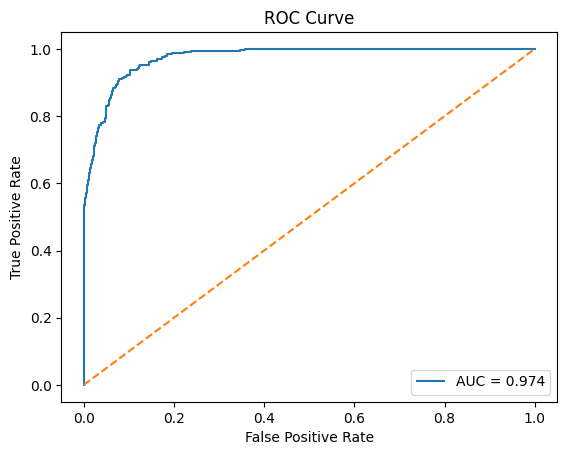

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
# Creating Random Forest pipeline
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight='balanced'
    ))
])

In [ ]:
# Train the model
rf_model.fit(X_train, y_train)

# Predictions
rf_y_pred = rf_model.predict(X_test)
rf_y_prob = rf_model.predict_proba(X_test)[:, 1]

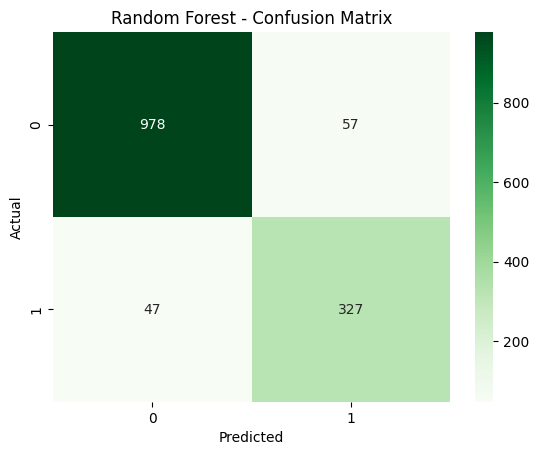

In [ ]:
# Confusion Matrix
rf_cm = confusion_matrix(y_test, rf_y_pred)

sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest - Confusion Matrix")
plt.show()

In [ ]:
# Classification Report
print("Random Forest Classification Report:\n")
print(classification_report(y_test, rf_y_pred))

Random Forest Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.94      0.95      1035
           1       0.85      0.87      0.86       374

    accuracy                           0.93      1409
   macro avg       0.90      0.91      0.91      1409
weighted avg       0.93      0.93      0.93      1409



Random Forest ROC-AUC Score: 0.9718


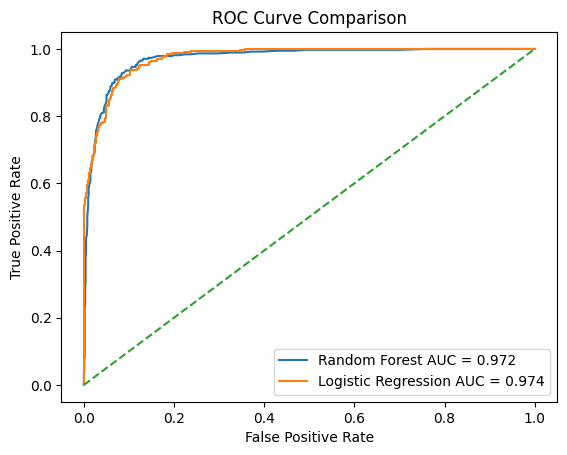

In [ ]:
# ROC-AUC
rf_roc_auc = roc_auc_score(y_test, rf_y_prob)
print("Random Forest ROC-AUC Score:", round(rf_roc_auc, 4))

# ROC Curve
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_y_prob)

plt.plot(rf_fpr, rf_tpr, label=f"Random Forest AUC = {rf_roc_auc:.3f}")
plt.plot(fpr, tpr, label=f"Logistic Regression AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

